In [1]:
import numpy as np
import pandas as pd
import altair as alt
import matplotlib.pyplot as plt
import matplotlib_fontja

## データサイエンスへの応用

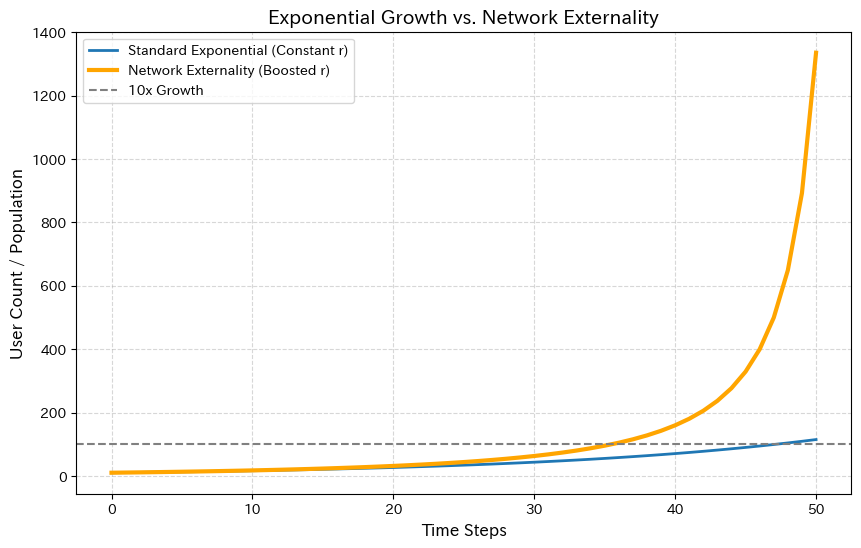

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 設定
steps = 50
initial_pop = 10
r_base = 0.05  # 基本の成長率 (5%)

# 1. 通常の指数成長 (a^t)
pop_exp = [initial_pop]
for _ in range(steps):
    pop_exp.append(pop_exp[-1] * (1 + r_base))

# 2. ネットワーク外部性成長 (r が N に比例して強化される)
pop_net = [initial_pop]
network_factor = 0.0005 # ネットワークの強さ
for _ in range(steps):
    # 現在の人口が多いほど、成長率がブーストされる
    current_r = r_base + (network_factor * pop_net[-1])
    pop_net.append(pop_net[-1] * (1 + current_r))

# 可視化
plt.figure(figsize=(10, 6))
plt.plot(pop_exp, label='Standard Exponential (Constant r)', linewidth=2)
plt.plot(pop_net, label='Network Externality (Boosted r)', linewidth=3, color='orange')
plt.axhline(y=initial_pop * 10, color='gray', linestyle='--', label='10x Growth')

plt.title('Exponential Growth vs. Network Externality', fontsize=14)
plt.xlabel('Time Steps', fontsize=12)
plt.ylabel('User Count / Population', fontsize=12)
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.show()

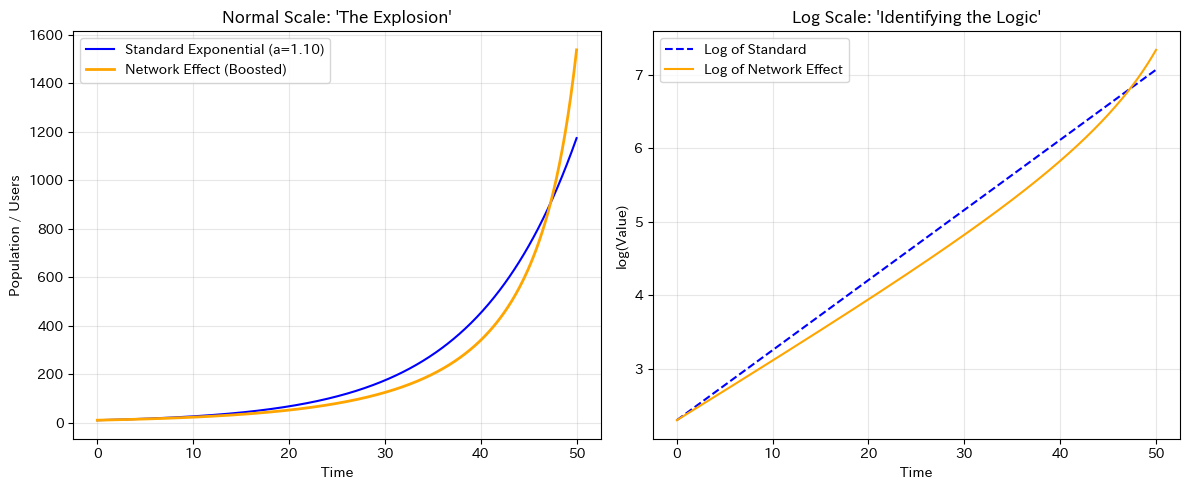

In [3]:
import numpy as np
import matplotlib.pyplot as plt

def demo_growth_comparison():
    # 期間設定
    t = np.linspace(0, 50, 500)
    
    # 1. 指数成長モデル (標準的な増殖)
    # N(t) = N0 * a^t
    a_standard = 1.10  # 成長率10%
    y_exp = 10 * (a_standard ** t)
    
    # 2. ネットワーク効果モデル (成長率そのものが規模に比例して上昇)
    # 簡易的に底aがNに応じて増大するシミュレーション
    y_net = [10]
    dt = t[1] - t[0]
    for i in range(len(t)-1):
        # 規模が大きいほど、次の成長率(r)がブーストされる
        current_r = 0.08 + (0.0001 * y_net[-1]) 
        next_val = y_net[-1] * (1 + current_r * dt)
        y_net.append(next_val)
    
    # プロット
    plt.figure(figsize=(12, 5))
    
    # 通常スケール: 爆発の見た目の違い
    plt.subplot(1, 2, 1)
    plt.plot(t, y_exp, label='Standard Exponential (a=1.10)', color='blue')
    plt.plot(t, y_net, label='Network Effect (Boosted)', color='orange', linewidth=2)
    plt.title("Normal Scale: 'The Explosion'")
    plt.xlabel("Time")
    plt.ylabel("Population / Users")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    # 対数スケール: 「直線」からの逸脱を見せる (次単元へのフック)
    plt.subplot(1, 2, 2)
    plt.plot(t, np.log(y_exp), '--', label='Log of Standard', color='blue')
    plt.plot(t, np.log(y_net), label='Log of Network Effect', color='orange')
    plt.title("Log Scale: 'Identifying the Logic'")
    plt.xlabel("Time")
    plt.ylabel("log(Value)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    demo_growth_comparison()

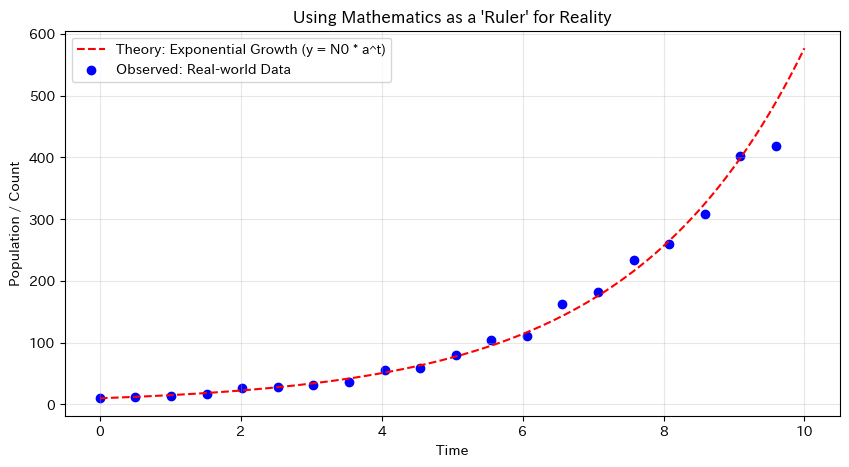

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def lecture_demo():
    t = np.linspace(0, 10, 100)
    N0 = 10
    a = 1.5 # 1.5倍ずつ増える自己増殖

    # 1. 理論モデル（指数関数）
    y_theory = N0 * (a ** t)

    # 2. 現実の観測データ（ノイズを加える）
    # 実際には環境要因などで理論通りにはいかないことを示す
    np.random.seed(42)
    y_observed = y_theory * (1 + np.random.normal(0, 0.1, len(t)))

    plt.figure(figsize=(10, 5))
    plt.plot(t, y_theory, 'r--', label="Theory: Exponential Growth (y = N0 * a^t)")
    plt.scatter(t[::5], y_observed[::5], color='blue', label="Observed: Real-world Data")
    
    plt.title("Using Mathematics as a 'Ruler' for Reality", fontsize=12)
    plt.xlabel("Time", fontsize=10)
    plt.ylabel("Population / Count", fontsize=10)
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

if __name__ == "__main__":
    lecture_demo()

Text(0.5, 1.0, '$0<c<1$のとき: $g(x)=0.8^{x}$')

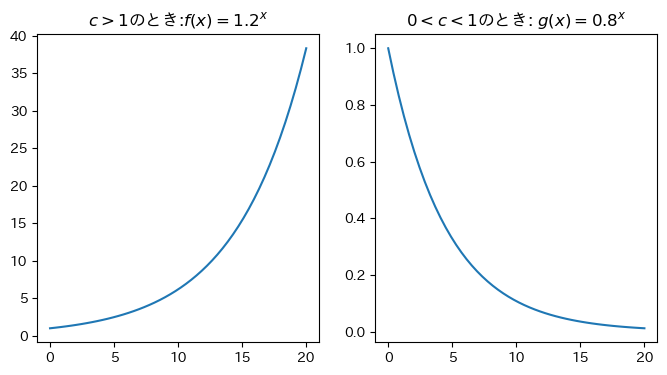

In [15]:
x = np.linspace(0, 20)

def fun(c,i):
    return c**i

y1 = [fun(1.2,i) for i in x] 
y2 = [fun(0.8,i) for i in x]

fig, axes = plt.subplots(1, 2, figsize=(8,4))
axes[0].plot(x, y1)
axes[0].set_title(r'$c>1$のとき:$f(x)=1.2^{x}$')
axes[1].plot(x, y2)
axes[1].set_title(r'$0<c<1$のとき: $g(x)=0.8^{x}$')

## 平均成長率

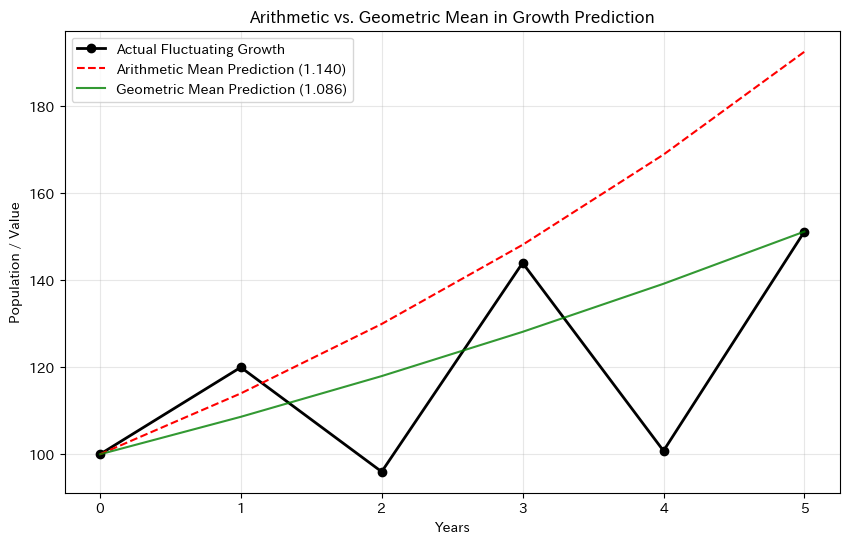

Final Actual Value: 151.20
Geometric Mean Result: 151.20 (Matched!)
Arithmetic Mean Result: 192.54 (Overestimated!)


In [6]:
import numpy as np
import matplotlib.pyplot as plt

def geometric_mean_demo():
    # 5年間の不規則な成長率（例：1.2倍, 0.8倍, 1.5倍, 0.7倍, 1.3倍）
    rates = np.array([1.2, 0.8, 1.5, 0.7, 1.5])
    years = np.arange(len(rates) + 1)
    
    # 実際の人口推移を計算
    pop_actual = [100] # 初期値100
    for r in rates:
        pop_actual.append(pop_actual[-1] * r)
    
    # 2種類の平均を計算
    arithmetic_avg = np.mean(rates)
    geometric_avg = np.prod(rates)**(1/len(rates))
    
    # 平均を用いた予測値
    pop_arithmetic = 100 * (arithmetic_avg ** years)
    pop_geometric = 100 * (geometric_avg ** years)
    
    plt.figure(figsize=(10, 6))
    plt.plot(years, pop_actual, 'ko-', label='Actual Fluctuating Growth', linewidth=2)
    plt.plot(years, pop_arithmetic, 'r--', label=f'Arithmetic Mean Prediction ({arithmetic_avg:.3f})')
    plt.plot(years, pop_geometric, 'g-', label=f'Geometric Mean Prediction ({geometric_avg:.3f})', alpha=0.8)
    
    plt.title("Arithmetic vs. Geometric Mean in Growth Prediction", fontsize=12)
    plt.xlabel("Years")
    plt.ylabel("Population / Value")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    print(f"Final Actual Value: {pop_actual[-1]:.2f}")
    print(f"Geometric Mean Result: {pop_geometric[-1]:.2f} (Matched!)")
    print(f"Arithmetic Mean Result: {pop_arithmetic[-1]:.2f} (Overestimated!)")

if __name__ == "__main__":
    geometric_mean_demo()

In [ ]:
# データ作成
x = np.linspace(-3, 3, 300)
bases = [0.5, 1.0, 2.0]

df = pd.concat([
    pd.DataFrame({
        "x": x,
        "y": a**x,
        "label": f"a = {a}"
    })
    for a in bases
])

# 基本グラフ
chart = alt.Chart(df).mark_line(size=4).encode(
    x=alt.X(
        "x:Q",
        title="x",
        axis=alt.Axis(labelFontSize=16, titleFontSize=20)
    ),
    y=alt.Y(
        "y:Q",
        title="y",
        scale=alt.Scale(domain=[0, 10]),
        axis=alt.Axis(labelFontSize=16, titleFontSize=20)
    ),
    color=alt.Color(
        "label:N",
        title="底 a",
        scale=alt.Scale(
            domain=["a = 0.5", "a = 1.0", "a = 2.0"],
            range=["#1f77b4", "#2ca02c", "#d62728"]
        ),
        legend=alt.Legend(labelFontSize=16, titleFontSize=18)
    )
).properties(
    width=600,
    height=400,
    title="指数関数 y = a^x の形の違い"
)

# (0,1) の強調
point = alt.Chart(pd.DataFrame({"x":[0], "y":[1]})).mark_point(size=120).encode(
    x="x:Q",
    y="y:Q"
)

# 補助線
vline = alt.Chart(pd.DataFrame({"x":[0]})).mark_rule(strokeDash=[4,4]).encode(x="x:Q")
hline = alt.Chart(pd.DataFrame({"y":[1]})).mark_rule(strokeDash=[4,4]).encode(y="y:Q")

# 合成
final_chart = chart + point + vline + hline

# PNG保存
final_chart.save("../images/exponential_base.png", scale_factor=2)

### ネイピア数のグラフ

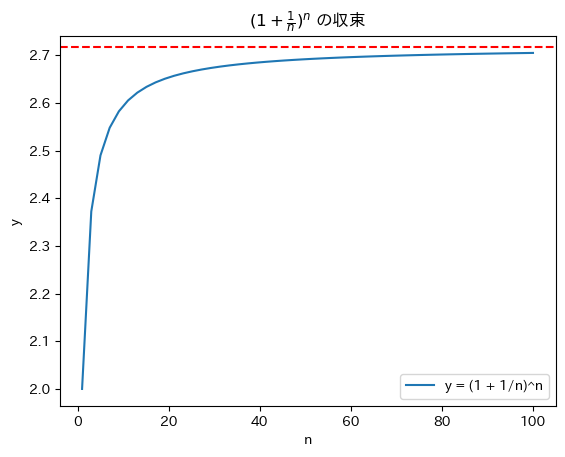

In [29]:
n = np.linspace(1,100,50)
y = (1 + 1/n)**n
df = pd.DataFrame({"n": n, "y": y})
df.plot(x="n", y="y", title=r"$(1 + \frac{1}{n})^n$ の収束", xlabel="n", ylabel="y")
plt.axhline(y=np.e, color="red", linestyle="--", label="e")
plt.legend(["y = (1 + 1/n)^n"])
plt.show()


In [30]:
np.e

2.718281828459045